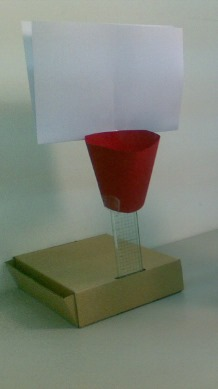

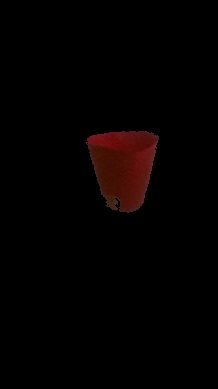

In [1]:
from google.colab.patches import cv2_imshow
import numpy as np
import cv2
redbasket=cv2.imread('/content/WhatsApp Image 2026-04-08 at 21.25.12.jpeg')
cv2_imshow(redbasket)
redrgb=cv2.cvtColor(redbasket,cv2.COLOR_BGR2RGB)
lower_red1 = np.array([50, 0, 0])
upper_red1 = np.array([255,45, 45])
mask1 = cv2.inRange(redrgb, lower_red1, upper_red1)
res = cv2.bitwise_and(redbasket,redbasket, mask= mask1)
cv2_imshow(res)

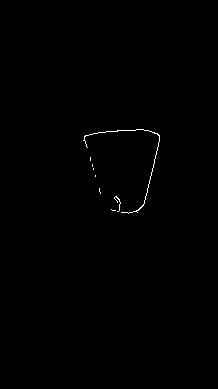

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/WhatsApp Image 2026-04-08 at 21.25.12.jpeg')

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv,(0,120,70),(10,255,255)) | cv2.inRange(hsv,(170,120,70),(180,255,255))

# clean mask slightly
mask = cv2.GaussianBlur(mask, (5,5), 0)

# edges on full image
edges = cv2.Canny(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 50, 150)

# keep edges only where red basket is
final = cv2.bitwise_and(edges, edges, mask=mask)

cv2_imshow(final)


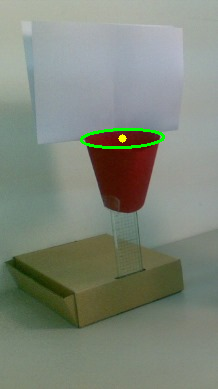

Center: (122, 138)


In [3]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

img = cv2.imread('/content/WhatsApp Image 2026-04-08 at 21.25.12.jpeg')
output = img.copy()
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv,(0,100,80),(10,255,255)) | cv2.inRange(hsv,(160,100,80),(180,255,255))

# largest contour (basket)
cnt = max(cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0], key=cv2.contourArea)
x,y,w,h = cv2.boundingRect(cnt)

# take top region (mouth)
roi = img[y:y+int(0.2*h), x:x+w]

# edges → ellipse
edges = cv2.Canny(cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY), 20, 80)
pts = np.vstack(cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0])

ellipse = cv2.fitEllipse(pts)
center = (int(ellipse[0][0])+x, int(ellipse[0][1])+y)

# draw
cv2.ellipse(img, ((center[0],center[1]), ellipse[1], ellipse[2]), (0,255,0), 2)
cv2.circle(img, center, 4, (0,255,255), -1)

cv2_imshow(img)
print("Center:", center)